In [325]:
import numpy as np
import matplotlib.pyplot as plt
import math
import yfinance as yf
import pandas as pd
import seaborn as sns
import seaborn.objects as so
from keras import Input
from keras import layers, Model
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop, Adam, SGD
import random
import sys
sys.path.append('../..')
#import ep.etools as apt
# import warnings
# warnings.filterwarnings( "ignore", module = "matplotlib\..*" )
from tqdm import tqdm
from pandas.tseries.offsets import DateOffset,BusinessDay

,Day-ahead,Month-ahead,Quarter-ahead,Summer 24,Winter 24,Year-Ahead,2 Year-Ahead
date_m,,,,,,,
2010-01-01,14.30,NaN,NaN,NaN,NaN,NaN,NaN
2010-01-04,16.25,13.70,NaN,NaN,NaN,NaN,NaN
2010-01-05,14.15,13.96,NaN,NaN,NaN,NaN,NaN
2010-01-06,14.65,13.80,NaN,NaN,NaN,NaN,NaN
2010-01-07,16.18,13.82,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
2024-04-22,29.78,29.20,29.91,NaN,34.61,33.40,29.72
2024-04-23,29.09,28.58,29.16,NaN,33.91,33.00,29.50
2024-04-24,30.11,29.33,29.80,NaN,34.38,33.58,29.83


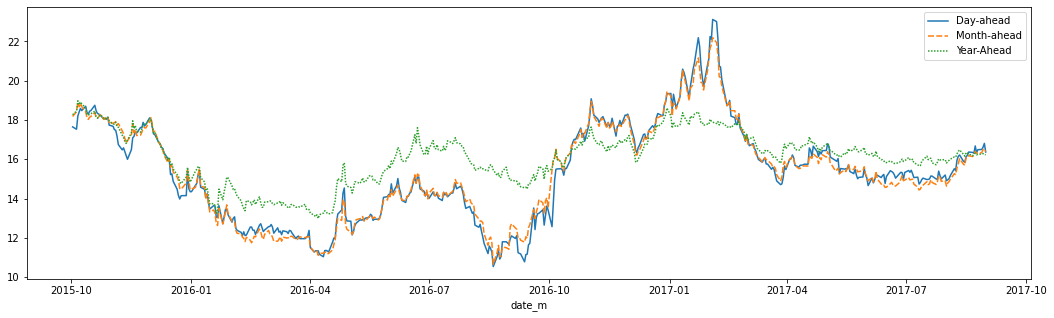

In [372]:
# dataCalendar = pd.read_csv('./data/bloc_ttf_calendar_prices.csv')
dataPrices = pd.read_csv('./data/bloc_ttf_prices.csv')
dataPrices['date_m'] = pd.to_datetime(dataPrices['date_m'])
dataPrices = dataPrices.set_index('date_m')
fig, ax = plt.subplots(figsize=(18,5))
# sns.set_palette("mako")
sns.lineplot(dataPrices[['Day-ahead','Month-ahead','Year-Ahead']][1500:2000], color='Blue'); #3390
#ax2 = plt.twinx()
#sns.lineplot(data=final['€/$'], ax=ax2 , color='grey')
dataPrices

# Lecture des informations de stock de Gaz depuis AGSI
* normalisation des données
* conversion en float
* conversion des dates

pour un Pays remplacer "type" par "country" et mettre en paramètre le code du pays : FR, BE, DE ...

In [373]:
import requests
params = {
    "type": "EU",
    "from": "2010-01-01",
    "size": 10000
}
header = {
  "x-key" : "99e18f932d22c9acf9c42f27d0b8b539" }

url = "https://agsi.gie.eu/api"
resp = requests.get(url=url, params=params, headers=header)
json = resp.json()
data = pd.json_normalize(json['data'])
data["gasInStorage"] = data["gasInStorage"].astype(float)
data["full"] = data["full"].astype(float)
#data["coveredCapacity"] = data["coveredCapacity"].astype(float)
data['date'] =pd.to_datetime(data['gasDayStart'], errors='coerce')
data = data.set_index(data['date'])
#data[["gasDayStart","gasInStorage"]]
#print(data)
print('Done')

Done


In [375]:
data

,name,code,url,updatedAt,gasDayStart,gasInStorage,consumption,consumptionFull,injection,withdrawal,...,injectionCapacity,withdrawalCapacity,contractedCapacity,availableCapacity,coveredCapacity,status,trend,full,info,date
date_m,,,,,,,,,,,,,,,,,,,,,
2024-04-28,EU,eu,eu,2024-04-29 15:03:10,2024-04-28,699.2852,3760.87,18.59,2038.74,498.8,...,11735.39,19846.53,-,-,100,E,0.14,61.75,[],2024-04-28
2024-04-27,EU,eu,eu,2024-04-29 15:02:11,2024-04-27,697.7495,3760.87,18.55,1544.27,559,...,11735.54,19846.15,-,-,100,E,0.02,61.61,[],2024-04-27
2024-04-26,EU,eu,eu,2024-04-29 15:02:01,2024-04-26,697.5106,3760.87,18.55,1153.59,1499.4,...,11735.4,19846.52,-,-,100,C,-0.03,61.59,[],2024-04-26
2024-04-25,EU,eu,eu,2024-04-29 15:01:52,2024-04-25,697.8624,3760.87,18.56,1131.62,2448,...,11735.14,19847.2,-,-,100,C,-0.12,61.62,[],2024-04-25
2024-04-24,EU,eu,eu,2024-04-29 14:06:37,2024-04-24,699.2010,3760.87,18.59,1115.99,2564.9,...,11725.92,19815.65,-,-,100,C,-0.13,61.74,[],2024-04-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011-01-05,EU,eu,eu,2023-04-18 10:46:51,2011-01-05,428.0276,3530,12.13,62.45,3640.9,...,5392.47,10316.05,-,-,-,C,-0.58,69.32,[],2011-01-05
2011-01-04,EU,eu,eu,2023-04-18 10:46:51,2011-01-04,431.5952,3530,12.23,44.25,3829.5,...,5392.62,10316.06,-,-,-,C,-0.6,69.89,[],2011-01-04
2011-01-03,EU,eu,eu,2023-04-18 10:46:51,2011-01-03,435.3212,3530,12.33,110.6,3323.2,...,5392.74,10316.04,-,-,-,C,-0.51,70.50,[],2011-01-03


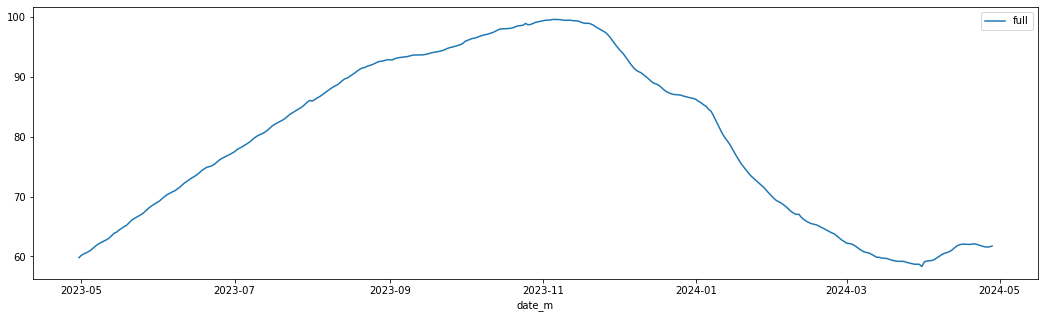

In [374]:
data['date_m'] = pd.to_datetime(data['gasDayStart'])
data = data.set_index('date_m')
fig, ax = plt.subplots(figsize=(18,5))
# sns.set_palette("mako")
sns.lineplot(data[['full']][0:365], color='Blue'); #3390

# Détermination du caractère Stationnaire de l'évolution du stockage de Gaz ...

In [376]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error

In [331]:
def adf_test(serie):
    adf = adfuller(serie,autolag='AIC')
    print('Test Dickey Fuller')
    print('Test adf',adf[0])
    print('p-Value',adf[1],' Mac Kinnon')
    print('used Lags',adf[2])
    print('Number of obs',adf[3])
    for k,v in adf[4].items():
        print('critical value',k,'->',v)
    print('max Info',adf[5])    

In [332]:
def kpss_test(serie):
    kpss_ = kpss(serie,regression="c", nlags="auto")
    print('Test KPSS')
    print('Test kpss',kpss_[0])
    print('p-Value',kpss_[1])
    print('used Lags',kpss_[2])
    for k,v in kpss_[3].items():
        print('critical value',k,'->',v)

In [377]:
data.dropna()
adf_test(data['full'])

Test Dickey Fuller
Test adf -9.642749488891768
p-Value 1.5055826457600424e-16  Mac Kinnon
used Lags 30
Number of obs 4836
critical value 1% -> -3.4317029310270737
critical value 5% -> -2.8621378447537276
critical value 10% -> -2.567088234253917
max Info -5479.160922612478


In [378]:
kpss_test(data['full'])

Test KPSS
Test kpss 0.19892377891882443
p-Value 0.1
used Lags 42
critical value 10% -> 0.347
critical value 5% -> 0.463
critical value 2.5% -> 0.574
critical value 1% -> 0.739


/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_87531/2657295217.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_ = kpss(serie,regression="c", nlags="auto")


Test Dickey Fuller
Test adf -1.4768430598939584
p-Value 0.5449340688288974  Mac Kinnon
used Lags 7
Number of obs 192
critical value 1% -> -3.4648754262570978
critical value 5% -> -2.876714157488788
critical value 10% -> -2.574858699001736
max Info 811.1039877307708
Test KPSS
Test kpss 0.9251643605075377
p-Value 0.01
used Lags 9
critical value 10% -> 0.347
critical value 5% -> 0.463
critical value 2.5% -> 0.574
critical value 1% -> 0.739


/var/folders/vw/2g_98rts7tzczmvh5hqt_qn00000gn/T/ipykernel_87531/2657295217.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_ = kpss(serie,regression="c", nlags="auto")


date_m
2023-07-24    29.84
2023-07-25    32.08
2023-07-26    28.61
2023-07-27    28.08
2023-07-28    25.24
              ...  
2024-04-22    29.78
2024-04-23    29.09
2024-04-24    30.11
2024-04-25    30.19
2024-04-26    28.62
Name: Day-ahead, Length: 200, dtype: float64

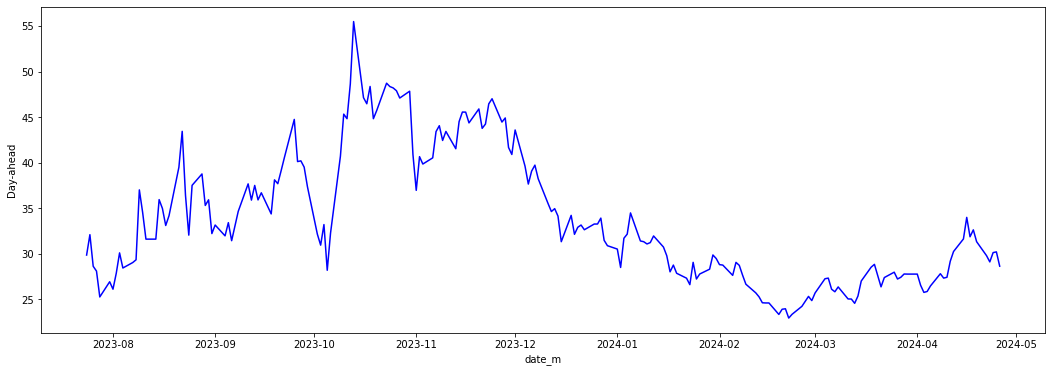

In [379]:
fig = plt.figure(figsize=(18,6))
sns.lineplot(data=dataPrices['Day-ahead'][-200:].dropna(),color='Blue')
adf_test(dataPrices['Day-ahead'][-200:].dropna())
kpss_test(dataPrices['Day-ahead'][-200:])
dataPrices['Day-ahead'][-200:]

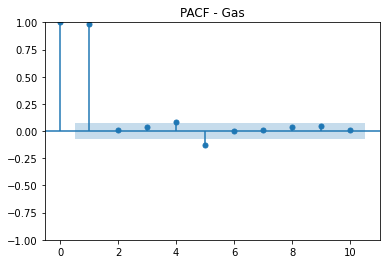

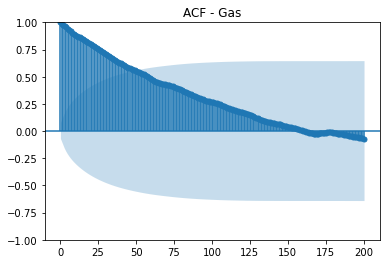

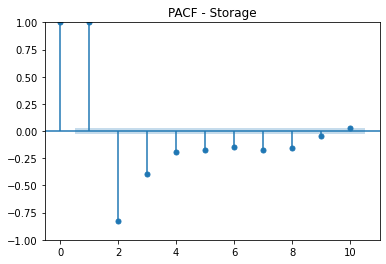

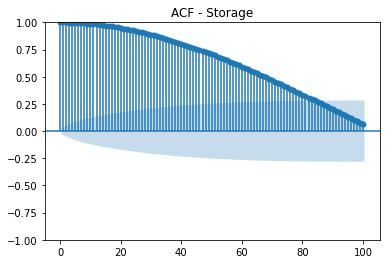

In [380]:
plot_pacf(dataPrices['Month-ahead'][3000:].dropna(),lags=10,title='PACF - Gas')
plot_acf(dataPrices['Month-ahead'][3000:].dropna(),lags=200,title='ACF - Gas')
plot_pacf(data['full'],lags=10,title='PACF - Storage')
plot_acf(data['full'],lags=100,title='ACF - Storage')
plt.show()

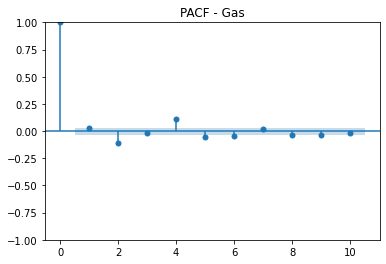

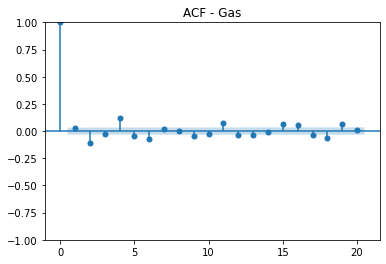

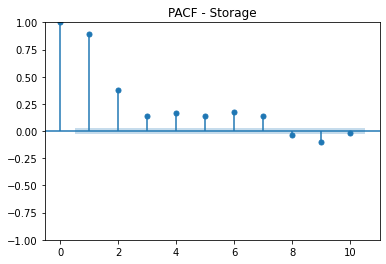

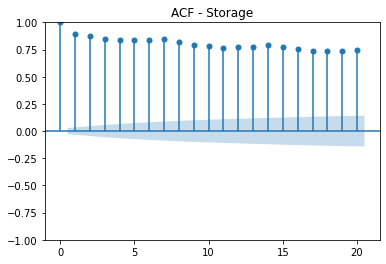

In [381]:
pricesDiff = dataPrices['Day-ahead'].diff().dropna()
dataDiff = data['full'][::-1].diff().dropna()
plot_pacf(pricesDiff,lags=10,title='PACF - Gas')
plot_acf(pricesDiff,lags=20,title='ACF - Gas')
plot_pacf(dataDiff,lags=10,title='PACF - Storage')
plot_acf(dataDiff,lags=20,title='ACF - Storage')
plt.show();

# Prévision de l'avolution du stockage

In [382]:
model=AutoReg(dataPrices['Day-ahead'][:],lags=120).fit()
model.summary()

/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:              Day-ahead   No. Observations:                 3736
Model:                   AutoReg(120)   Log Likelihood              -10045.191
Method:               Conditional MLE   S.D. of innovations              3.892
Date:                Mon, 29 Apr 2024   AIC                          20334.381
Time:                        21:59:01   BIC                          21089.942
Sample:                    06-18-2010   HQIC                         20603.585
                         - 04-26-2024                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1722      0.095      1.821      0.069      -0.013       0.358
Day-ahead.L1       1.0191      0.017     61.358      0.000       0.987       1.052
Day-ahead.L2      -0.1029      0.024     -4.340      0.000      -0.149      -0.056
Day-ahead.L3       0.0508      0.024      2.141      0.032       0.004       0.097
Day-ahead.L4       0.1375      0.024      5.802      0.000       0.091       0.184
Day-ahead.L5      -0.1657      0.024     -6.967      0.000      -0.212      -0.119
Day-ahead.L6       0.0040      0.024      0.166      0.868      -0.043       0.051
Day-ahead.L7       0.0686      0.024      2.867      0.004       0.022       0.116
Day-ahead.L8      -0.0250      0.024     -1.043      0.297      -0.072       0.022
Day-ahead.L9       0.0092      0.024      0.384      0.701      -0.038       0.056
Day-ahead.L10     -0.0235      0.024     -0.981      0.327      -0.070       0.023
Day-ahead.L11      0.0707      0.024      2.952      0.003       0.024       0.118
Day-ahead.L12     -0.0910      0.024     -3.797      0.000      -0.138      -0.044
Day-ahead.L13      0.0592      0.024      2.468      0.014       0.012       0.106
Day-ahead.L14     -0.0248      0.024     -1.036      0.300      -0.072       0.022
Day-ahead.L15      0.0339      0.024      1.413      0.158      -0.013       0.081
Day-ahead.L16      0.0335      0.024      1.399      0.162      -0.013       0.080
Day-ahead.L17     -0.0775      0.024     -3.239      0.001      -0.124      -0.031
Day-ahead.L18     -0.0369      0.024     -1.543      0.123      -0.084       0.010
Day-ahead.L19      0.0935      0.024      3.907      0.000       0.047       0.140
Day-ahead.L20     -0.0623      0.024     -2.596      0.009      -0.109      -0.015
Day-ahead.L21     -0.0339      0.024     -1.412      0.158      -0.081       0.013
Day-ahead.L22      0.0908      0.024      3.783      0.000       0.044       0.138
Day-ahead.L23     -0.0031      0.024     -0.128      0.898      -0.050       0.044
Day-ahead.L24     -0.0296      0.024     -1.232      0.218      -0.077       0.017
Day-ahead.L25      0.0933      0.024      3.883      0.000       0.046       0.140
Day-ahead.L26     -0.1344      0.024     -5.587      0.000      -0.182      -0.087
Day-ahead.L27      0.0198      0.024      0.819      0.413      -0.028       0.067
Day-ahead.L28     -0.0251      0.024     -1.040      0.298      -0.072       0.022
Day-ahead.L29     -0.0180      0.024     -0.744      0.457      -0.065       0.029
Day-ahead.L30      0.0938      0.024      3.887      0.000       0.047       0.141
Day-ahead.L31     -0.0736      0.024     -3.042      0.002      -0.121      -0.026
Day-ahead.L32     -0.0120      0.024     -0.497      0.619      -0.059       0.035
Day-ahead.L33      0.0747      0.024      3.086      0.002       0.027       0.122
Day-ahead.L34     -0.0576      0.024     -2.378      0.017      -0.105      -0.010
Day-ahead.L35      0.0515      0.024      2.123      0.034       0.004       0.099
Day-

RMSE 2.0478482829058042


/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/deterministic.py:302: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


<AxesSubplot:xlabel='date_m', ylabel='Day-ahead'>

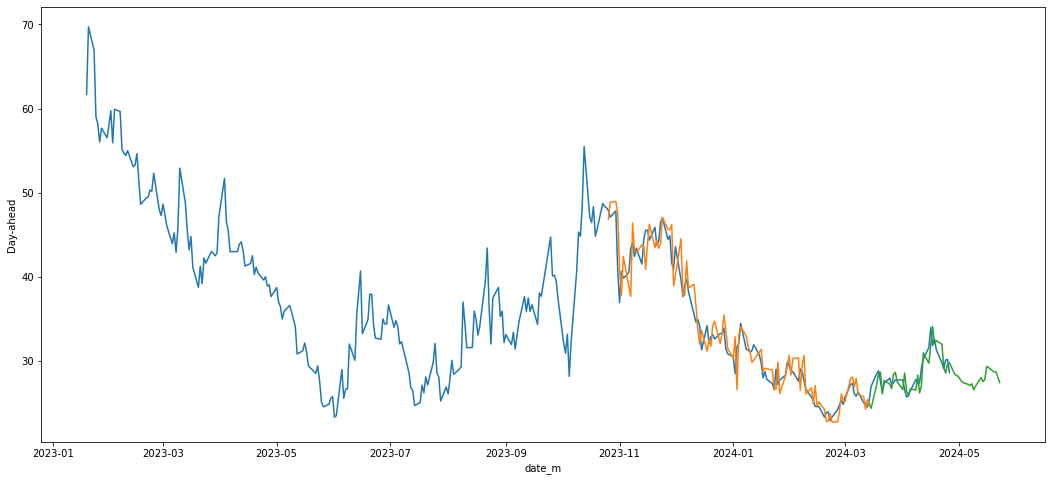

In [383]:
vmin= 3604
vmax=3704
control = model.predict(start=vmin,end=vmax,dynamic=False)
futur = model.predict(start=vmax,end=(vmax+50),dynamic=False)
rmse = math.sqrt(mean_squared_error(dataPrices['Day-ahead'][vmin:(vmax+1)],control))
print('RMSE',rmse)
fig = plt.figure(figsize=(18,8))
sns.lineplot(dataPrices['Day-ahead'][(vmin-200):])
sns.lineplot(control)
sns.lineplot(futur)

# ARIMA model

In [ ]:
#!pip install pmdarima

In [384]:
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

In [385]:
# all = dataPrices['Day-ahead'].dropna()
all = pricesDiff #data['full'][::-1].diff().dropna()
train = all.iloc[:-30]
test = all.iloc[-30:]
step = auto_arima(all,trace=True,suppress_warnings=True)
step.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=21213.068, Time=1.15 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=21317.103, Time=0.12 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=21316.262, Time=0.17 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=21315.499, Time=0.19 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=21315.106, Time=0.10 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=21284.334, Time=0.49 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=21276.472, Time=0.41 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=21211.497, Time=0.99 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=21257.304, Time=0.69 sec
 ARIMA(4,0,2)(0,0,0)[0] intercept   : AIC=21208.384, Time=1.07 sec
 ARIMA(4,0,1)(0,0,0)[0] intercept   : AIC=21223.715, Time=0.58 sec
 ARIMA(5,0,2)(0,0,0)[0] intercept   : AIC=21208.872, Time=1.31 sec
 ARIMA(4,0,3)(0,0,0)[0] intercept   : AIC=21205.582, Time=2.27 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=21209.375, Time=1.23 sec
 ARIMA(5,0,3)(0,0,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 3735
Model:               SARIMAX(5, 0, 3)   Log Likelihood              -10588.995
Date:                Mon, 29 Apr 2024   AIC                          21195.991
Time:                        22:00:23   BIC                          21252.020
Sample:                    01-04-2010   HQIC                         21215.921
                         - 04-26-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6230      0.026     24.073      0.000       0.572       0.674
ar.L2         -0.1752      0.029     -6.111      0.000      -0.231      -0.119
ar.L3          0.4638      0.025     18.275      0.000       0.414       0.514
ar.L4          0.1083      0.007     16.613      0.000       0.096       0.121
ar.L5         -0.0792      0.005    -14.513      0.000      -0.090      -0.068
ma.L1         -0.5888      0.027    -22.198      0.000      -0.641      -0.537
ma.L2          0.0648      0.028      2.307      0.021       0.010       0.120
ma.L3         -0.4447      0.025    -17.803      0.000      -0.494      -0.396
sigma2        16.9902      0.075    226.607      0.000      16.843      17.137
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):            702803.00
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):              74.83   Skew:                             0.46
Prob(H) (two-sided):                  0.00   Kurtosis:                        70.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [386]:
all.describe()

count    3735.000000
mean        0.003834
std         4.196937
min       -60.020000
25%        -0.350000
50%         0.000000
75%         0.350000
max        54.820000
Name: Day-ahead, dtype: float64

/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:              Day-ahead   No. Observations:                 3705
Model:                 ARIMA(5, 0, 3)   Log Likelihood              -10517.718
Date:                Mon, 29 Apr 2024   AIC                          21055.436
Time:                        22:00:42   BIC                          21117.610
Sample:                    01-04-2010   HQIC                         21077.561
                         - 03-15-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.063      0.015      0.988      -0.122       0.124
ar.L1          0.6239      0.026     23.989      0.000       0.573       0.675
ar.L2         -0.1785      0.029     -6.205      0.000      -0.235      -0.122
ar.L3          0.4674      0.026     18.207      0.000       0.417       0.518
ar.L4          0.1087      0.007     16.503      0.000       0.096       0.122
ar.L5         -0.0783      0.006    -13.947      0.000      -0.089      -0.067
ma.L1         -0.5913      0.027    -22.184      0.000      -0.644      -0.539
ma.L2          0.0679      0.028      2.406      0.016       0.013       0.123
ma.L3         -0.4487      0.025    -17.677      0.000      -0.498      -0.399
sigma2        17.0933      0.076    224.150      0.000      16.944      17.243
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            686845.23
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):              75.89   Skew:                             0.50
Prob(H) (two-sided):                  0.00   Kurtosis:                        69.69
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

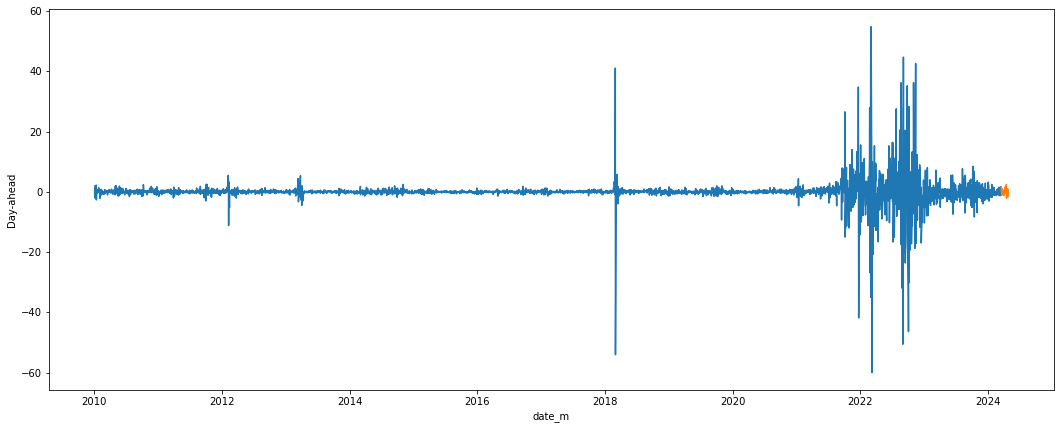

In [387]:
# print(train.shape)
fig = plt.figure(figsize=(18,7))
sns.lineplot(train[:]);
sns.lineplot(test[:]);
model = ARIMA(train,order=(5,0,3))
model = model.fit()
model.summary()

/Users/rky/miniforge3/envs/tf-M1/lib/python3.10/site-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['type']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


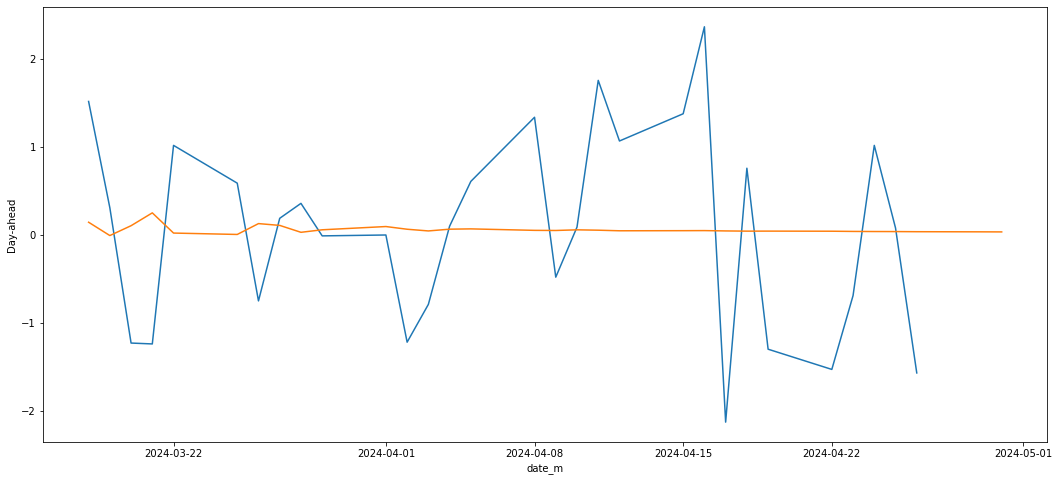

In [389]:
start = len(train)
end = start + len(test) + 1
pred = model.predict(start=start, end=end, type='levels')
fig = plt.figure(figsize=(18,8))
sns.lineplot(train[4000:]);
sns.lineplot(test);
sns.lineplot(pred);
# pred

# Extraire la saisonnaité

In [390]:
from statsmodels.tsa.seasonal import seasonal_decompose

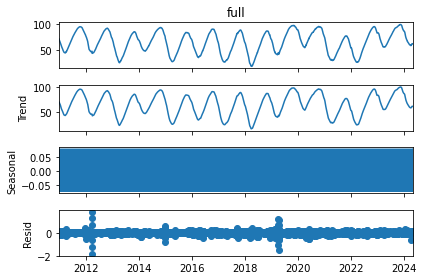

In [391]:
saison = seasonal_decompose(data['full'][::-1].dropna())
saison.plot();

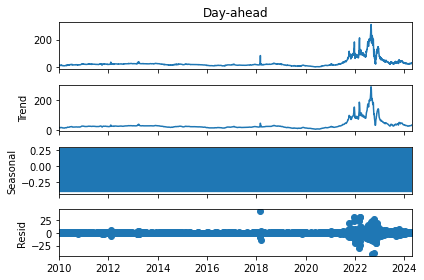

In [392]:
saison = seasonal_decompose(dataPrices['Day-ahead'].dropna())
saison.plot();